<a href="https://colab.research.google.com/github/atharvsalokhe30/GenAI_Project_Practice-/blob/main/Compare_Activation_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, LeakyReLU
import matplotlib.pyplot as plt

In [3]:
# load & preprocess the mnist data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize pixel values and reshape
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255.0

# convert labels to one hot encoding vectors
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# Function to build CNN model with given Activation
def build_model(activation_type):
    model = Sequential()

    # Input layer
    model.add(Input(shape=(28,28,1)))

    #conv layer
    model.add(Conv2D(32, (3,3)))
    if activation_type == 'leakyrelu':
      model.add(LeakyReLU(alpha=0.1))
    else:
      model.add(tf.keras.layers.Activation(activation_type))

    #pooling + Dense layers
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(64))
    if activation_type == 'leakyrelu':
      model.add(LeakyReLU(alpha=0.3))
    else:
      model.add(tf.keras.layers.Activation(activation_type))

    #output layer
    model.add(Dense(10, activation='softmax'))

    #compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [5]:
# train and compare models
activations = ['relu', 'sigmoid', 'leakyrelu']
histories = {}

for act in activations:
    print(f"\n Training model with {act.upper()} activation...")
    model = build_model(act)
    history = model.fit(x_train, y_train, epochs=5, batch_size=128,
                        validation_data=(x_test, y_test), verbose=1)
    histories[act] = history



 Training model with RELU activation...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9244 - loss: 0.2609 - val_accuracy: 0.9704 - val_loss: 0.0952
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9759 - loss: 0.0828 - val_accuracy: 0.9808 - val_loss: 0.0639
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9834 - loss: 0.0560 - val_accuracy: 0.9838 - val_loss: 0.0483
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9871 - loss: 0.0433 - val_accuracy: 0.9843 - val_loss: 0.0519
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9906 - loss: 0.0344 - val_accuracy: 0.9839 - val_loss: 0.0464

 Training model with SIGMOID activation...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.1059 - loss: 2.3100 - val_accuracy: 0.0974 - val_loss: 2.3040
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.1067 - loss: 2.3035 - val_accuracy: 0.1032 - val_loss: 2.3029
Epoch 3/5
46

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9348 - loss: 0.2288 - val_accuracy: 0.9728 - val_loss: 0.0880
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.9780 - loss: 0.0764 - val_accuracy: 0.9792 - val_loss: 0.0649
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9834 - loss: 0.0559 - val_accuracy: 0.9828 - val_loss: 0.0521
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9867 - loss: 0.0442 - val_accuracy: 0.9837 - val_loss: 0.0487
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9890 - loss: 0.0363 - val_accuracy: 0.9832 - val_loss: 0.0461


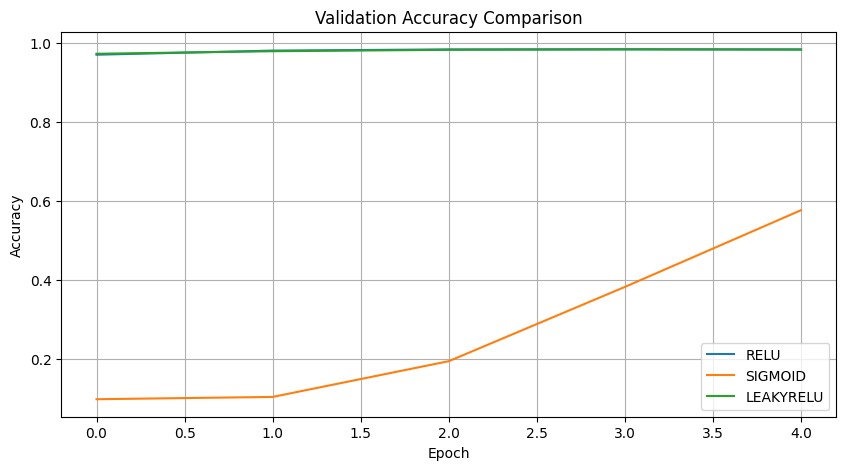

In [7]:
# plot validation accuracy comparision
plt.figure(figsize=(10, 5))
for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act.upper())
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

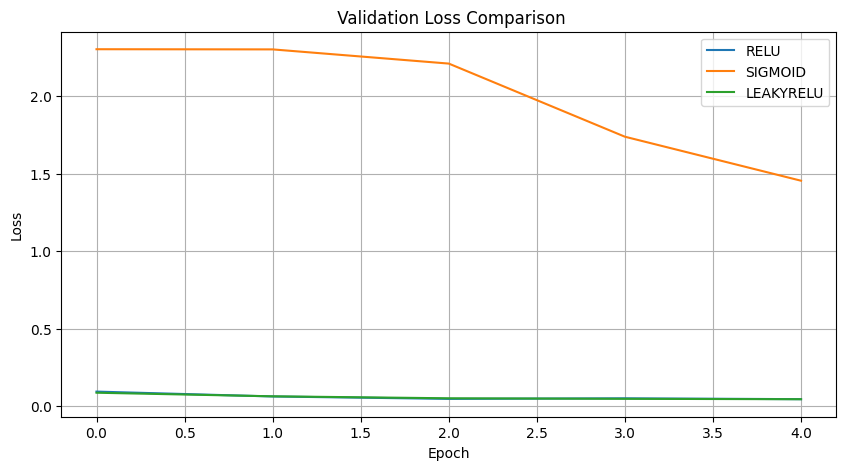

In [10]:
# plot validation loss comparision
plt.figure(figsize=(10, 5))
for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act.upper())
plt.title(" Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()